In [1]:
from google.colab import files

uploaded = files.upload()

Saving ipl_male_json.zip to ipl_male_json.zip
Saving odis_male_json.zip to odis_male_json.zip
Saving t20s_male_json.zip to t20s_male_json.zip
Saving tests_male_json.zip to tests_male_json.zip


In [2]:
import os
import zipfile

zip_files = [
    "ipl_male_json.zip",
    "odis_male_json.zip",
    "t20s_male_json.zip",
    "tests_male_json.zip"
]

for zip_file in zip_files:
    if os.path.exists(zip_file):
        folder = zip_file.replace(".zip", "")

        with zipfile.ZipFile(zip_file, "r") as zip_ref:
            zip_ref.extractall(folder)

        print(f"Extracted: {zip_file}")
    else:
        print(f"Not found: {zip_file}")

Extracted: ipl_male_json.zip
Extracted: odis_male_json.zip
Extracted: t20s_male_json.zip
Extracted: tests_male_json.zip


In [3]:
for folder in [
    "ipl_male_json",
    "odis_male_json",
    "t20s_male_json",
    "tests_male_json"
]:
    if os.path.exists(folder):
        files_list = [
            f for f in os.listdir(folder)
            if f.endswith(".json")
        ]

        print(f"{folder}: {len(files_list)} JSON files")

ipl_male_json: 1243 JSON files
odis_male_json: 2571 JSON files
t20s_male_json: 3539 JSON files
tests_male_json: 894 JSON files


In [4]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

In [5]:
def calculate_innings_stats(innings):
    """
    Calculate total runs and wickets from one innings.
    """

    total_runs = 0
    total_wickets = 0

    for over in innings.get("overs", []):
        for delivery in over.get("deliveries", []):

            runs = delivery.get("runs", {})
            total_runs += runs.get("total", 0)

            wickets = delivery.get("wickets", [])
            total_wickets += len(wickets)

    return total_runs, total_wickets

In [6]:
def load_cricket_dataset(folder, format_name):

    records = []

    json_files = [
        f for f in os.listdir(folder)
        if f.endswith(".json")
    ]

    for filename in json_files:

        filepath = os.path.join(folder, filename)

        try:
            with open(filepath, "r", encoding="utf-8") as file:
                match = json.load(file)

            info = match.get("info", {})

            teams = info.get("teams", [])

            if len(teams) < 2:
                continue

            team1 = teams[0]
            team2 = teams[1]

            venue = info.get("venue", "Unknown")

            toss = info.get("toss", {})

            toss_winner = toss.get("winner", "Unknown")
            toss_decision = toss.get("decision", "Unknown")

            outcome = info.get("outcome", {})

            winner = outcome.get("winner")

            result = outcome.get("result")

            if winner is None:
                if result:
                    winner = result
                else:
                    winner = "Unknown"

            dates = info.get("dates", [])

            if isinstance(dates, list) and len(dates) > 0:
                match_date = dates[0]
            else:
                match_date = None

            # Calculate innings statistics
            innings = match.get("innings", [])

            team_runs = {}
            team_wickets = {}

            for inning in innings:

                batting_team = inning.get("team")

                if not batting_team:
                    continue

                runs, wickets = calculate_innings_stats(inning)

                team_runs[batting_team] = team_runs.get(
                    batting_team, 0
                ) + runs

                team_wickets[batting_team] = team_wickets.get(
                    batting_team, 0
                ) + wickets

            record = {
                "format": format_name,
                "date": match_date,
                "team1": team1,
                "team2": team2,
                "venue": venue,
                "toss_winner": toss_winner,
                "toss_decision": toss_decision,
                "winner": winner,
                "result": result,
                "team1_runs": team_runs.get(team1, 0),
                "team2_runs": team_runs.get(team2, 0),
                "team1_wickets": team_wickets.get(team1, 0),
                "team2_wickets": team_wickets.get(team2, 0)
            }

            records.append(record)

        except Exception as e:
            print(f"Error reading {filename}: {e}")

    return pd.DataFrame(records)

In [7]:
ipl_df = load_cricket_dataset(
    "ipl_male_json",
    "IPL"
)

odi_df = load_cricket_dataset(
    "odis_male_json",
    "ODI"
)

t20_df = load_cricket_dataset(
    "t20s_male_json",
    "T20"
)

test_df = load_cricket_dataset(
    "tests_male_json",
    "TEST"
)

In [8]:
print("IPL matches :", len(ipl_df))
print("ODI matches :", len(odi_df))
print("T20 matches :", len(t20_df))
print("TEST matches:", len(test_df))

print(
    "\nTotal matches:",
    len(ipl_df) + len(odi_df) + len(t20_df) + len(test_df)
)

IPL matches : 1243
ODI matches : 2571
T20 matches : 3539
TEST matches: 894

Total matches: 8247


In [9]:
df = pd.concat(
    [ipl_df, odi_df, t20_df, test_df],
    ignore_index=True
)

print("Combined dataset shape:", df.shape)

df.head()

Combined dataset shape: (8247, 13)


,format,date,team1,team2,venue,toss_winner,toss_decision,winner,result,team1_runs,team2_runs,team1_wickets,team2_wickets
0,IPL,2011-04-13,Pune Warriors,Kochi Tuskers Kerala,Dr DY Patil Sports Academy,Kochi Tuskers Kerala,bat,Pune Warriors,None,151,148,6,8
1,IPL,2014-05-23,Kings XI Punjab,Rajasthan Royals,"Punjab Cricket Association Stadium, Mohali",Rajasthan Royals,field,Kings XI Punjab,None,179,163,4,8
2,IPL,2015-05-12,Delhi Daredevils,Chennai Super Kings,Shaheed Veer Narayan Singh International Stadium,Chennai Super Kings,bat,Delhi Daredevils,None,120,119,4,6
3,IPL,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,M.Chinnaswamy Stadium,Royal Challengers Bangalore,bat,Royal Challengers Bangalore,None,157,142,8,9
4,IPL,2012-05-25,Delhi Daredevils,Chennai Super Kings,"MA Chidambaram Stadium, Chepauk",Delhi Daredevils,field,Chennai Super Kings,None,136,222,10,5


In [10]:
print("Number of records:", df.shape[0])
print("Number of features:", df.shape[1])

print("\nFormats:")
print(df["format"].value_counts())

print("\nColumns:")
for column in df.columns:
    print("-", column)

Number of records: 8247
Number of features: 13

Formats:
format
T20     3539
ODI     2571
IPL     1243
TEST     894
Name: count, dtype: int64

Columns:
- format
- date
- team1
- team2
- venue
- toss_winner
- toss_decision
- winner
- result
- team1_runs
- team2_runs
- team1_wickets
- team2_wickets


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 8247
Columns: 13


In [ ]:
print(df.dtypes)

format           object
date             object
team1            object
team2            object
venue            object
toss_winner      object
toss_decision    object
winner           object
result           object
team1_runs        int64
team2_runs        int64
team1_wickets     int64
team2_wickets     int64
dtype: object


In [ ]:
missing_values = df.isnull().sum()

print(missing_values)

format              0
date                0
team1               0
team2               0
venue               0
toss_winner         0
toss_decision       0
winner              0
result           7809
team1_runs          0
team2_runs          0
team1_wickets       0
team2_wickets       0
dtype: int64


In [ ]:
print(
    missing_values[
        missing_values > 0
    ]
)

result    7809
dtype: int64


In [ ]:
print(
    missing_values[
        missing_values > 0
    ]
)

result    7809
dtype: int64


In [ ]:
unique_values = df.nunique()

print(unique_values)

format              4
date             4697
team1             128
team2             126
venue             476
toss_winner       128
toss_decision       2
winner            125
result              3
team1_runs        735
team2_runs        706
team1_wickets      22
team2_wickets      22
dtype: int64


In [ ]:
print(df.describe(include="all"))

       format        date  team1     team2  \
count    8247        8247   8247      8247   
unique      4        4697    128       126   
top       T20  2026-05-08  India  Pakistan   
freq     3539          10    541       543   
mean      NaN         NaN    NaN       NaN   
std       NaN         NaN    NaN       NaN   
min       NaN         NaN    NaN       NaN   
25%       NaN         NaN    NaN       NaN   
50%       NaN         NaN    NaN       NaN   
75%       NaN         NaN    NaN       NaN   
max       NaN         NaN    NaN       NaN   

                                      venue toss_winner toss_decision winner  \
count                                  8247        8247          8247   8247   
unique                                  476         128             2    125   
top     Dubai International Cricket Stadium     England         field  India   
freq                                    212         486          4349    601   
mean                                    NaN    

In [ ]:
print(df.describe())

        team1_runs   team2_runs  team1_wickets  team2_wickets
count  8247.000000  8247.000000    8247.000000    8247.000000
mean    220.239117   198.395780       7.893537       7.433612
std     140.237862   131.806809       4.039439       4.464393
min       0.000000     0.000000       0.000000       0.000000
25%     140.000000   125.000000       5.000000       4.000000
50%     179.000000   162.000000       8.000000       7.000000
75%     249.000000   227.000000      10.000000      10.000000
max    1078.000000   892.000000      21.000000      21.000000


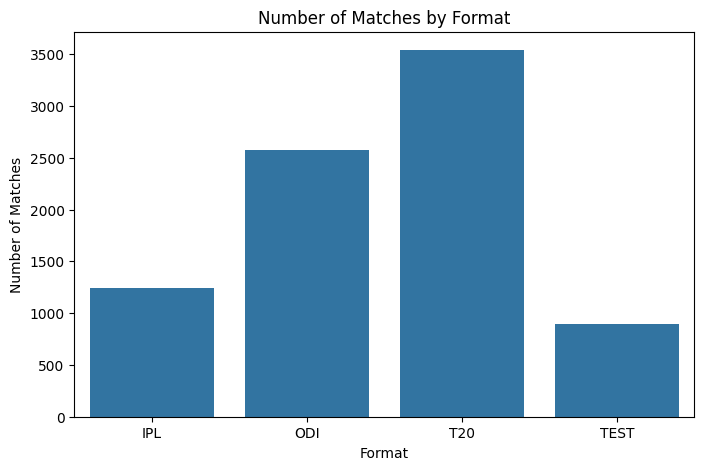

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="format"
)

plt.title("Number of Matches by Format")
plt.xlabel("Format")
plt.ylabel("Number of Matches")

plt.show()

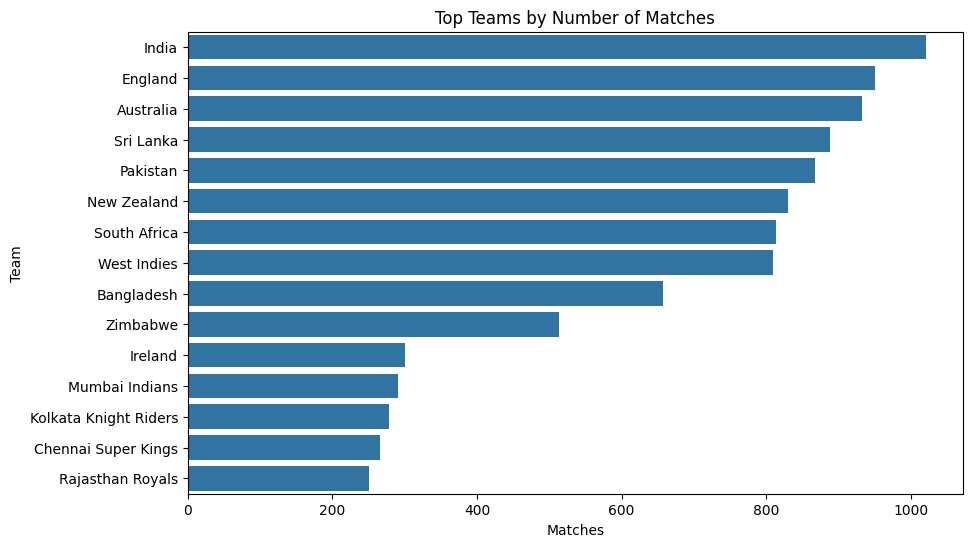

In [ ]:
team_counts = Counter(
    df["team1"].dropna()
) + Counter(
    df["team2"].dropna()
)

team_counts_df = pd.DataFrame(
    team_counts.most_common(15),
    columns=["Team", "Matches"]
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=team_counts_df,
    x="Matches",
    y="Team"
)

plt.title("Top Teams by Number of Matches")

plt.show()

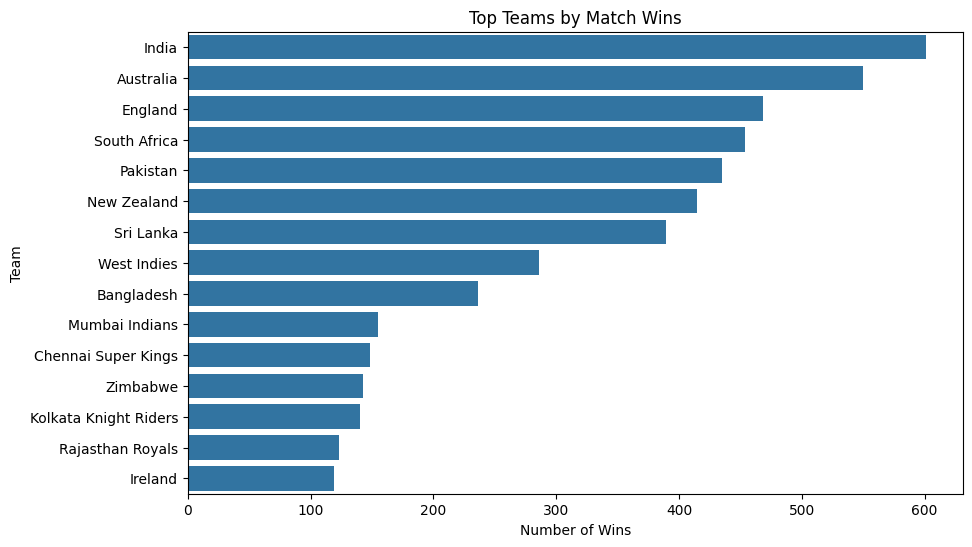

In [ ]:
winner_counts = (
    df[df["winner"].isin(df["team1"].tolist() + df["team2"].tolist())]
    ["winner"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=winner_counts.values,
    y=winner_counts.index
)

plt.title("Top Teams by Match Wins")
plt.xlabel("Number of Wins")
plt.ylabel("Team")

plt.show()

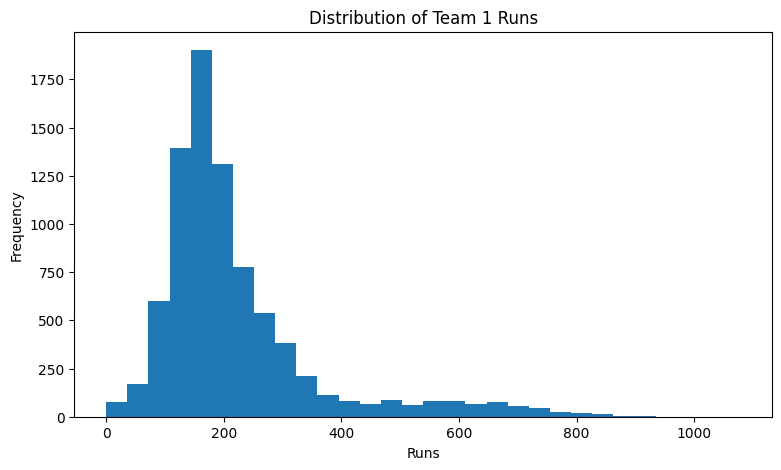

In [ ]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["team1_runs"],
    bins=30
)

plt.title("Distribution of Team 1 Runs")
plt.xlabel("Runs")
plt.ylabel("Frequency")

plt.show()

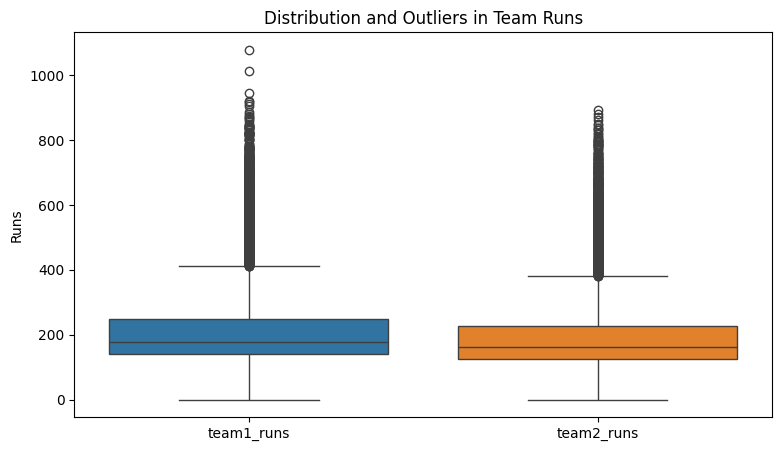

In [ ]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df[
        ["team1_runs", "team2_runs"]
    ]
)

plt.title("Distribution and Outliers in Team Runs")
plt.ylabel("Runs")

plt.show()

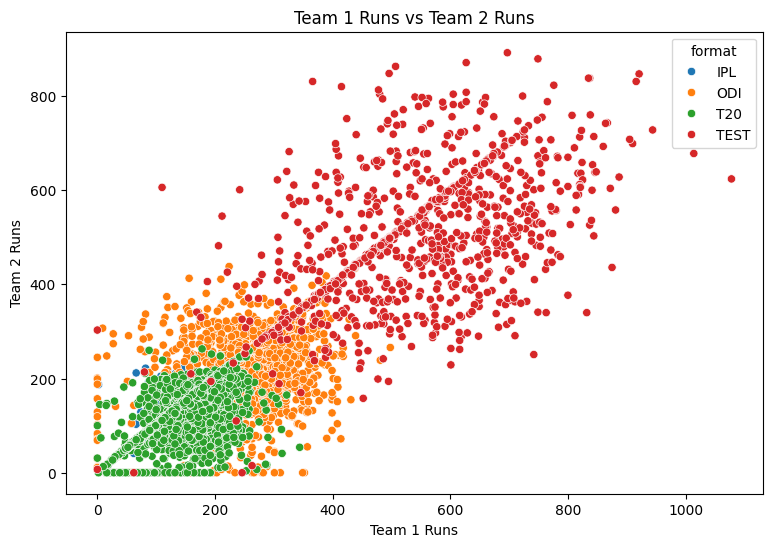

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="team1_runs",
    y="team2_runs",
    hue="format"
)

plt.title("Team 1 Runs vs Team 2 Runs")
plt.xlabel("Team 1 Runs")
plt.ylabel("Team 2 Runs")

plt.show()

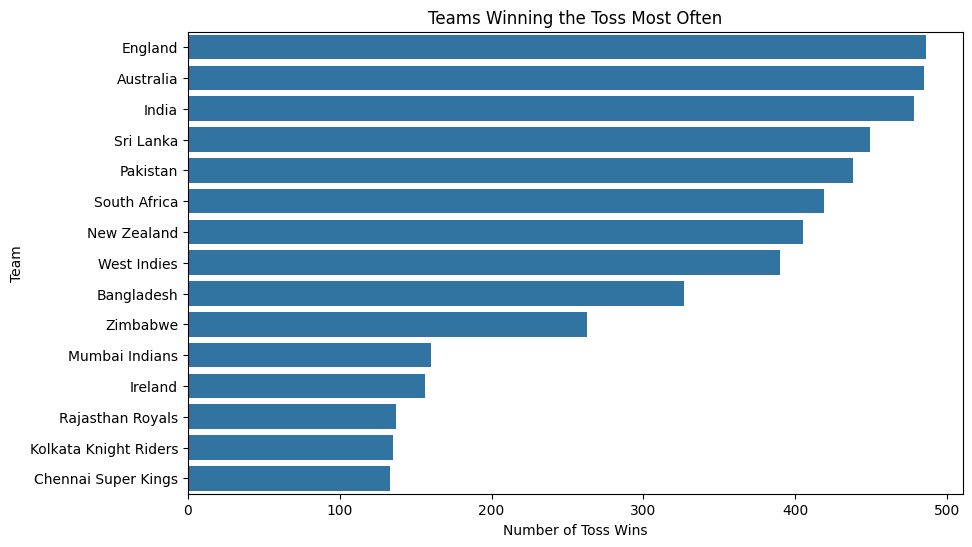

In [ ]:
toss_wins = (
    df["toss_winner"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=toss_wins.values,
    y=toss_wins.index
)

plt.title("Teams Winning the Toss Most Often")
plt.xlabel("Number of Toss Wins")
plt.ylabel("Team")

plt.show()

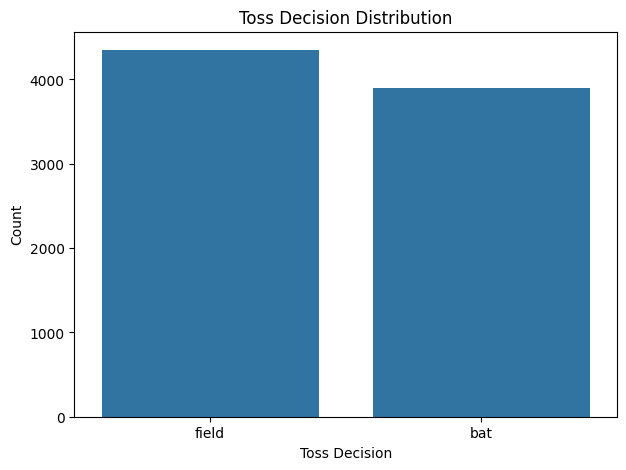

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="toss_decision"
)

plt.title("Toss Decision Distribution")
plt.xlabel("Toss Decision")
plt.ylabel("Count")

plt.show()

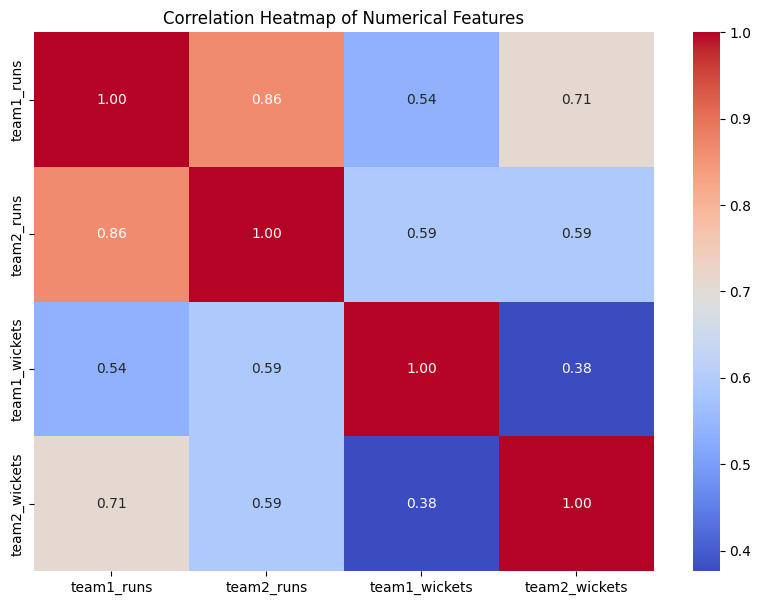

In [ ]:
numeric_df = df.select_dtypes(
    include=["int64", "float64"]
)

correlation = numeric_df.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

In [ ]:
print("Missing values before preprocessing:")
print(df.isnull().sum())

Missing values before preprocessing:
format              0
date                0
team1               0
team2               0
venue               0
toss_winner         0
toss_decision       0
winner              0
result           7809
team1_runs          0
team2_runs          0
team1_wickets       0
team2_wickets       0
dtype: int64


In [ ]:
before = len(df)

df = df.drop_duplicates()

after = len(df)

print("Records before:", before)
print("Records after :", after)
print("Duplicates removed:", before - after)

Records before: 8247
Records after : 8247
Duplicates removed: 0


In [ ]:
numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

df[numeric_columns] = df[numeric_columns].fillna(0)

In [ ]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

for column in categorical_columns:
    df[column] = df[column].fillna("Unknown")

In [ ]:
print("Missing values after preprocessing:")
print(df.isnull().sum())

Missing values after preprocessing:
format           0
date             0
team1            0
team2            0
venue            0
toss_winner      0
toss_decision    0
winner           0
result           0
team1_runs       0
team2_runs       0
team1_wickets    0
team2_wickets    0
dtype: int64


In [ ]:
print("Negative Team 1 runs:")
print((df["team1_runs"] < 0).sum())

print("Negative Team 2 runs:")
print((df["team2_runs"] < 0).sum())

print("Negative wickets:")
print(
    (df["team1_wickets"] < 0).sum()
    +
    (df["team2_wickets"] < 0).sum()
)

Negative Team 1 runs:
0
Negative Team 2 runs:
0
Negative wickets:
0


In [ ]:
categorical_features = df.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical Features:")
for feature in categorical_features:
    print("-", feature)

print("\nNumerical Features:")
for feature in numerical_features:
    print("-", feature)

Categorical Features:
- format
- date
- team1
- team2
- venue
- toss_winner
- toss_decision
- winner
- result

Numerical Features:
- team1_runs
- team2_runs
- team1_wickets
- team2_wickets


In [ ]:
def detect_outliers_iqr(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return outliers, lower_bound, upper_bound


for column in [
    "team1_runs",
    "team2_runs",
    "team1_wickets",
    "team2_wickets"
]:

    outliers, lower, upper = detect_outliers_iqr(
        df,
        column
    )

    print("\n", column)
    print("Lower bound:", lower)
    print("Upper bound:", upper)
    print("Outliers:", len(outliers))


 team1_runs
Lower bound: -23.5
Upper bound: 412.5
Outliers: 731

 team2_runs
Lower bound: -28.0
Upper bound: 380.0
Outliers: 713

 team1_wickets
Lower bound: -2.5
Upper bound: 17.5
Outliers: 488

 team2_wickets
Lower bound: -5.0
Upper bound: 19.0
Outliers: 420


In [ ]:
print("Final dataset shape:", df.shape)

print("\nFirst 5 records:")
display(df.head())

print("\nFinal missing values:")
print(df.isnull().sum().sum())

print("\nFinal duplicate count:")
print(df.duplicated().sum())

Final dataset shape: (8247, 13)

First 5 records:


,format,date,team1,team2,venue,toss_winner,toss_decision,winner,result,team1_runs,team2_runs,team1_wickets,team2_wickets
0,IPL,2025-05-26,Mumbai Indians,Punjab Kings,"Sawai Mansingh Stadium, Jaipur",Punjab Kings,field,Punjab Kings,Unknown,184,187,7,3
1,IPL,2026-04-07,Rajasthan Royals,Mumbai Indians,"Barsapara Cricket Stadium, Guwahati",Mumbai Indians,field,Rajasthan Royals,Unknown,150,123,3,9
2,IPL,2023-04-23,Chennai Super Kings,Kolkata Knight Riders,"Eden Gardens, Kolkata",Kolkata Knight Riders,field,Chennai Super Kings,Unknown,235,186,4,8
3,IPL,2023-04-02,Mumbai Indians,Royal Challengers Bangalore,"M Chinnaswamy Stadium, Bengaluru",Royal Challengers Bangalore,field,Royal Challengers Bangalore,Unknown,171,172,7,2
4,IPL,2022-04-15,Kolkata Knight Riders,Sunrisers Hyderabad,"Brabourne Stadium, Mumbai",Sunrisers Hyderabad,field,Sunrisers Hyderabad,Unknown,175,176,8,3



Final missing values:
0

Final duplicate count:
0


In [ ]:
df.to_csv(
    "cricvision_combined_dataset.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


In [ ]:
from google.colab import files

files.download(
    "cricvision_combined_dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("===== DATASET DIMENSIONS =====")

print("Number of records (rows):", df.shape[0])
print("Number of features (columns):", df.shape[1])

===== DATASET DIMENSIONS =====
Number of records (rows): 8247
Number of features (columns): 13


In [ ]:
print("===== FEATURES / COLUMNS =====")

for i, column in enumerate(df.columns, 1):
    print(i, ".", column)

===== FEATURES / COLUMNS =====
1 . format
2 . date
3 . team1
4 . team2
5 . venue
6 . toss_winner
7 . toss_decision
8 . winner
9 . result
10 . team1_runs
11 . team2_runs
12 . team1_wickets
13 . team2_wickets


In [ ]:
print("===== DATA TYPES =====")

print(df.dtypes)

===== DATA TYPES =====
format           object
date             object
team1            object
team2            object
venue            object
toss_winner      object
toss_decision    object
winner           object
result           object
team1_runs        int64
team2_runs        int64
team1_wickets     int64
team2_wickets     int64
dtype: object


In [ ]:
print("===== MISSING VALUES =====")

missing = df.isnull().sum()

print(missing)

===== MISSING VALUES =====
format              0
date                0
team1               0
team2               0
venue               0
toss_winner         0
toss_decision       0
winner              0
result           7809
team1_runs          0
team2_runs          0
team1_wickets       0
team2_wickets       0
dtype: int64


In [ ]:
print("===== MISSING VALUE PERCENTAGE =====")

missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage.round(2))

===== MISSING VALUE PERCENTAGE =====
format            0.00
date              0.00
team1             0.00
team2             0.00
venue             0.00
toss_winner       0.00
toss_decision     0.00
winner            0.00
result           94.69
team1_runs        0.00
team2_runs        0.00
team1_wickets     0.00
team2_wickets     0.00
dtype: float64


In [ ]:
print("===== DUPLICATE RECORDS =====")

duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

===== DUPLICATE RECORDS =====
Number of duplicate records: 0


In [ ]:
print("===== UNIQUE VALUES =====")

for column in df.columns:
    print(
        f"{column}: {df[column].nunique()} unique values"
    )

===== UNIQUE VALUES =====
format: 4 unique values
date: 4697 unique values
team1: 128 unique values
team2: 126 unique values
venue: 476 unique values
toss_winner: 128 unique values
toss_decision: 2 unique values
winner: 125 unique values
result: 3 unique values
team1_runs: 735 unique values
team2_runs: 706 unique values
team1_wickets: 22 unique values
team2_wickets: 22 unique values


In [ ]:
print("===== NUMERICAL STATISTICAL SUMMARY =====")

print(df.describe())

===== NUMERICAL STATISTICAL SUMMARY =====
        team1_runs   team2_runs  team1_wickets  team2_wickets
count  8247.000000  8247.000000    8247.000000    8247.000000
mean    220.239117   198.395780       7.893537       7.433612
std     140.237862   131.806809       4.039439       4.464393
min       0.000000     0.000000       0.000000       0.000000
25%     140.000000   125.000000       5.000000       4.000000
50%     179.000000   162.000000       8.000000       7.000000
75%     249.000000   227.000000      10.000000      10.000000
max    1078.000000   892.000000      21.000000      21.000000


In [ ]:
print("===== CATEGORICAL STATISTICAL SUMMARY =====")

print(df.describe(include="object"))

===== CATEGORICAL STATISTICAL SUMMARY =====
       format        date  team1     team2  \
count    8247        8247   8247      8247   
unique      4        4697    128       126   
top       T20  2026-05-08  India  Pakistan   
freq     3539          10    541       543   

                                      venue toss_winner toss_decision winner  \
count                                  8247        8247          8247   8247   
unique                                  476         128             2    125   
top     Dubai International Cricket Stadium     England         field  India   
freq                                    212         486          4349    601   

           result  
count         438  
unique          3  
top     no result  
freq          188  


In [ ]:
print("===== CATEGORICAL VARIABLES =====")

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

for column in categorical_columns:
    print("-", column)

===== CATEGORICAL VARIABLES =====
- format
- date
- team1
- team2
- venue
- toss_winner
- toss_decision
- winner
- result


In [ ]:
print("===== NUMERICAL VARIABLES =====")

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

for column in numerical_columns:
    print("-", column)

===== NUMERICAL VARIABLES =====
- team1_runs
- team2_runs
- team1_wickets
- team2_wickets


In [12]:
important_features = [
    "elo_diff",
    "win_rate_diff",
    "recent_form_diff",
    "avg_runs_diff",
    "avg_wickets_diff",
    "run_rate_diff",
    "team_1_h2h_win_rate",
    "venue_win_rate_diff",
    "toss_winner_diff",
    "bat_first_diff"
]

In [13]:
available_features = [
    feature
    for feature in important_features
    if feature in df.columns
]

print("Available important features:")
print(available_features)

Available important features:
[]


In [14]:
# Display actual columns
print("Actual columns in dataset:")
print(df.columns.tolist())

# Normalize column names for matching
normalized_columns = {
    col.strip().lower().replace(" ", "_").replace("-", "_"): col
    for col in df.columns
}

important_features = [
    "elo_diff",
    "win_rate_diff",
    "recent_form_diff",
    "avg_runs_diff",
    "avg_wickets_diff",
    "run_rate_diff",
    "team_1_h2h_win_rate",
    "venue_win_rate_diff",
    "toss_winner_diff",
    "bat_first_diff"
]

# Find matching columns
available_features = []

for feature in important_features:
    key = feature.strip().lower().replace(" ", "_").replace("-", "_")

    if key in normalized_columns:
        available_features.append(normalized_columns[key])

print("\nAvailable important features:")
print(available_features)

Actual columns in dataset:
['format', 'date', 'team1', 'team2', 'venue', 'toss_winner', 'toss_decision', 'winner', 'result', 'team1_runs', 'team2_runs', 'team1_wickets', 'team2_wickets']

Available important features:
[]


In [15]:
import matplotlib.pyplot as plt

for feature in available_features:

    plt.figure(figsize=(8, 5))

    plt.hist(
        df[feature].dropna(),
        bins=20
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [18]:
print("===== OUTLIER ANALYSIS =====")

for feature in available_features:

    data = df[feature].dropna()

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data < lower_bound) |
        (data > upper_bound)
    ]

    print(f"\nFeature: {feature}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Number of outliers:", len(outliers))

===== OUTLIER ANALYSIS =====
